# Generative Modeling with VAE and GANs
Practical implementation using PyTorch and MNIST.

## Setup

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

x = torch.randn(5, device="cuda")
print(x)

True
1
Tesla T4
tensor([-2.0175,  0.6399,  0.3784,  1.6698, -1.1558], device='cuda:0')


In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


## Variational Autoencoder

In [2]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU()
        )
        self.mu = nn.Linear(400, latent_dim)
        self.logvar = nn.Linear(400, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.mu(h), self.logvar(h)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

def vae_loss(recon, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl


In [3]:
batch_size = 128
latent_dim = 20
epochs = 10
lr = 1e-3

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


vae = VAE(latent_dim).to(device)
optimizer = optim.Adam(vae.parameters(), lr=lr)

for epoch in range(epochs):
    vae.train()
    total_loss = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch [{epoch+1}/{epochs}]",
        leave=True
    )


    for x, _ in progress_bar:
        x = x.view(-1, 784).to(device)

        optimizer.zero_grad()
        recon, mu, logvar = vae(x)
        loss = vae_loss(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            batch_loss=loss.item() / x.size(0)
        )


    print(f"Epoch {epoch+1}: Loss = {total_loss/len(train_loader.dataset):.4f}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 509kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.38MB/s]


Epoch [1/10]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: Loss = 163.8692


Epoch [2/10]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: Loss = 121.2332


...

Epoch 8: Loss = 107.2475


Epoch [9/10]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9: Loss = 106.6735


Epoch [10/10]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10: Loss = 106.2736


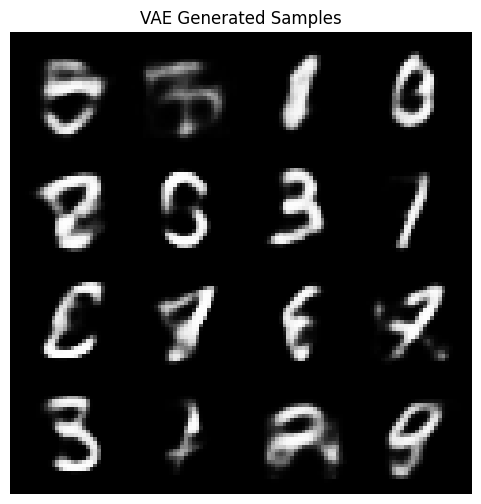

In [6]:
vae.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = vae.decoder(z).view(-1, 1, 28, 28).cpu()

grid = make_grid(samples, nrow=4)
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0))
plt.axis('off')
plt.title("VAE Generated Samples")
plt.show()


## Generative Adversarial Network

In [7]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.ReLU(True),

            nn.Unflatten(1, (128, 7, 7)),

            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                64, 1,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)



class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),

            nn.Linear(128 * 7 * 7, 1)
        )

    def forward(self, x):
        return self.net(x)



In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

batch_size = 128
latent_dim = 100
epochs = 50


train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


In [9]:

G = Generator(latent_dim).to(device)
D = Discriminator().to(device)


criterion = nn.BCEWithLogitsLoss()

g_optimizer = optim.Adam(
    G.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

d_optimizer = optim.Adam(
    D.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

for epoch in range(epochs):
    G.train()
    D.train()

    d_epoch_loss = 0
    g_epoch_loss = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch [{epoch+1}/{epochs}]",
        leave=True
    )

    for real_images, _ in progress_bar:

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.full(
            (batch_size, 1),
            0.9,
            device=device
        )

        fake_labels = torch.full(
            (batch_size, 1),
            0.1,
            device=device
        )

        # ======================
        # Train Discriminator
        # ======================

        d_optimizer.zero_grad()

        # Real images
        real_outputs = D(real_images)
        real_loss = criterion(
            real_outputs,
            real_labels
        )

        # Fake images
        z = torch.randn(
            batch_size,
            latent_dim,
            device=device
        )

        fake_images = G(z)

        fake_outputs = D(
            fake_images.detach()
        )

        fake_loss = criterion(
            fake_outputs,
            fake_labels
        )

        d_loss = real_loss + fake_loss

        d_loss.backward()
        d_optimizer.step()

        # ======================
        # Train Generator
        # ======================

        g_optimizer.zero_grad()

        z = torch.randn(
            batch_size,
            latent_dim,
            device=device
        )

        generated_images = G(z)

        outputs = D(generated_images)

        g_loss = criterion(
            outputs,
            real_labels
        )

        g_loss.backward()
        g_optimizer.step()

        # Statistics
        d_epoch_loss += d_loss.item()
        g_epoch_loss += g_loss.item()

        progress_bar.set_postfix(
            D_Loss=f"{d_loss.item():.3f}",
            G_Loss=f"{g_loss.item():.3f}"
        )

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"D Loss: {d_epoch_loss / len(train_loader):.4f} | "
        f"G Loss: {g_epoch_loss / len(train_loader):.4f}"
    )

    avg_g_loss = g_epoch_loss / len(train_loader)


torch.save(
            G.state_dict(),
            "generator.pth"
        )



Epoch [1/50]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/50 | D Loss: 0.7527 | G Loss: 1.9777


Epoch [2/50]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/50 | D Loss: 0.8351 | G Loss: 1.4585


Epoch [3/50]:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 15/50 | D Loss: 0.8312 | G Loss: 1.6125


Epoch [16/50]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 16/50 | D Loss: 0.8289 | G Loss: 1.6316


Epoch [17/50]:   0%|          | 0/469 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [12]:
G.load_state_dict(
    torch.load(
        'generator.pth',
        map_location=device
    )
)

G.eval()

Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=6272, bias=True)
    (1): ReLU(inplace=True)
    (2): Unflatten(dim=1, unflattened_size=(128, 7, 7))
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Tanh()
  )
)

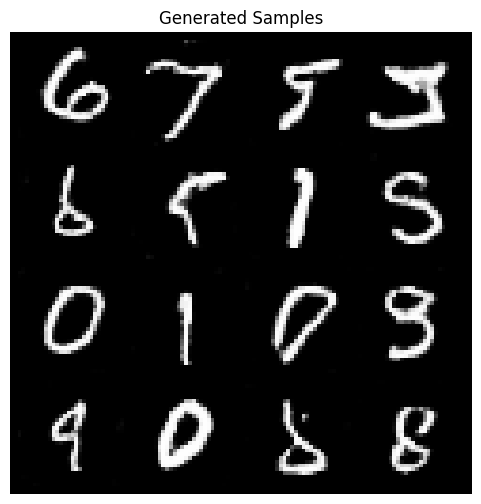

In [14]:
with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)

    samples = G(z).cpu()

samples = (samples + 1) / 2

grid = make_grid(samples, nrow=4)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title('Generated Samples')
plt.show()